In [4]:
import pymc as pm; import arviz as az; import sys; import numpy as np; import pickle
import nutpie; import pytensor.tensor as pt; import matplotlib.pyplot as plt
sys.path.append(r'C:\Users\awast\OneDrive\Desktop\MKM')
from _CO_Oxidation.common import kb_eV, T, kb_J, h, F, N_A
from _CO_Oxidation import wrapper_base as wp
from _CO_Oxidation.wrapper_base import plot_posteriors, plot_model_fits, plot_coverages, plot_drc

C_KOH_list = np.array([0.25, 0.5, 1]) # in M 
P_CO_list = 0.01*np.array([0.1, 1, 10, 100]) # in atm 
experiments_data = pickle.load(open('import_Pd100_base_replicates.pkl', 'rb'))
wp.process_experimental_data(experiments_data, C_KOH_list, P_CO_list)
E_in = wp.E_in; P_CO_in = wp.P_CO_in; C_KOH_in = wp.C_KOH_in

def fit_and_evaluate(model, draws=1000, tune=2000, chains=4, cores=4, init_mean=None, target_accept=0.9):
    compiled_model = nutpie.compile_pymc_model(model)
    trace = nutpie.sample(compiled_model, draws=draws, tune=tune, chains=chains, cores=cores, init_mean=init_mean, target_accept=target_accept)
    pm.compute_log_likelihood(trace, progressbar=False, model=model)
    loo = az.loo(trace, pointwise=True)
    print(loo); az.plot_khat(loo); plt.title("Pareto k diagnostic"); plt.show()
    trace = wp.add_post_sampling_observables(trace)
    return trace, loo

def observables(log_rate):
    pm.Deterministic('log_rate', log_rate)
    rate_model = pt.exp(log_rate)
    sigma_rel = pm.Gamma('sigma_rel', alpha=2, beta=20)
    sigma_base = pm.HalfNormal('sigma_base', sigma=1e-2)
    exponent =  pm.HalfNormal('exponent', sigma=1)
    sigma_model = pt.sqrt(sigma_base**2 + (sigma_rel**2)*(rate_model ** exponent))
    # sigma_total = pt.sqrt(wp.rate_SD_obs**2 + sigma_model**2)
    rate = pm.StudentT('rate', nu=4, mu=rate_model, sigma=sigma_model, observed=wp.rate_obs_matrix)
    return rate

# LH 

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.37,7
,3000,0,0.38,31
,3000,0,0.41,15
,3000,0,0.36,15


Computed from 4000 posterior samples and 1476 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  1766.90    59.73
p_loo        5.09        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     1476  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



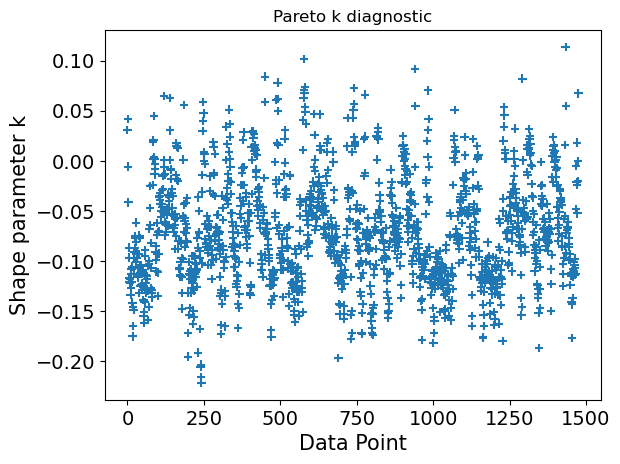

In [5]:
with pm.Model() as LH:
    '''
    1. CO + * <-> CO* (QEA)
    2. CO* + OH* -> COOH* + * (RDS)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2) # at 0V_SHE
    Gact2_0 = pm.Normal('Gact2_0', mu=0.7, sigma=0.2)

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    Gact2 = Gact2_0
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_k2 = np.log(kb_J*T/h) - Gact2/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH_Pd = log_K4 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO)
    log_theta_Pd = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH_Pd]), axis=0)
    log_theta_CO = term_CO + log_theta_Pd
    log_theta_OH_Pd = term_OH_Pd + log_theta_Pd

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH_star = pm.Deterministic('theta_OH_star', pt.exp(log_theta_OH_Pd))
    theta_empty_Pd = pm.Deterministic('theta_empty_Pd', pt.exp(log_theta_Pd))

    # Rate expression
    log_rate = log_k2 + log_theta_CO + log_theta_OH_Pd
    rate = observables(log_rate) 

trace_LH, loo_LH = fit_and_evaluate(LH)

             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0  -0.032  0.003  -0.037   -0.027      0.000    0.000    2161.0    2525.0    1.0
deltaG4_0   0.116  0.005   0.107    0.126      0.000    0.000    1471.0    1964.0    1.0
Gact2_0     0.671  0.003   0.666    0.676      0.000    0.000    1541.0    2174.0    1.0
sigma_rel   0.621  0.034   0.559    0.685      0.001    0.001    1706.0    2218.0    1.0
sigma_base  0.000  0.000   0.000    0.001      0.000    0.000    2362.0    1167.0    1.0
exponent    0.606  0.011   0.586    0.627      0.000    0.000    2087.0    2361.0    1.0


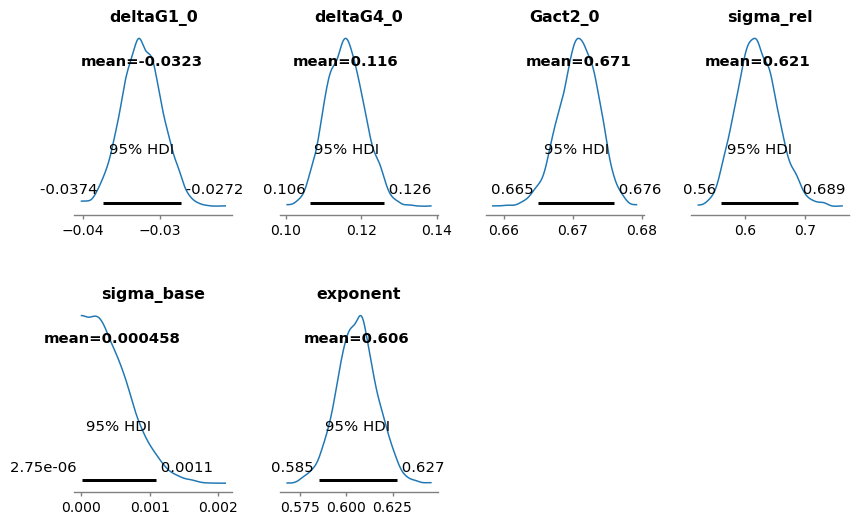

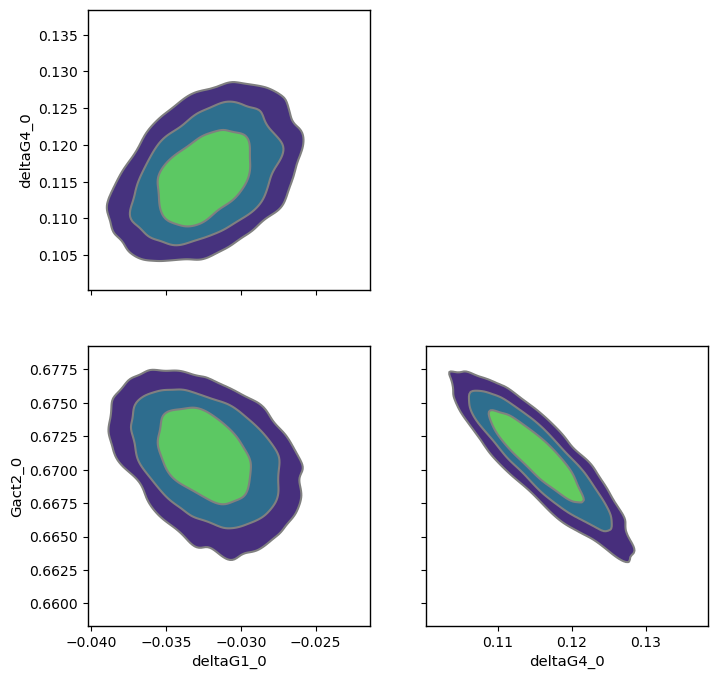

Sampling: [rate]


rate: 0.627


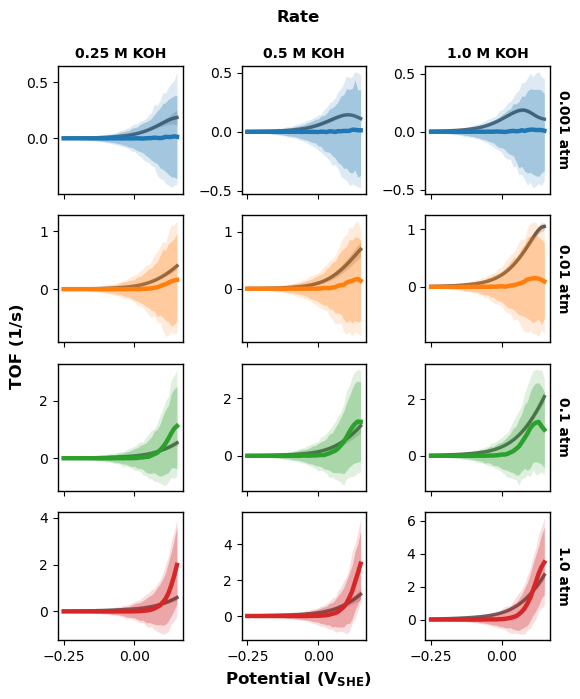

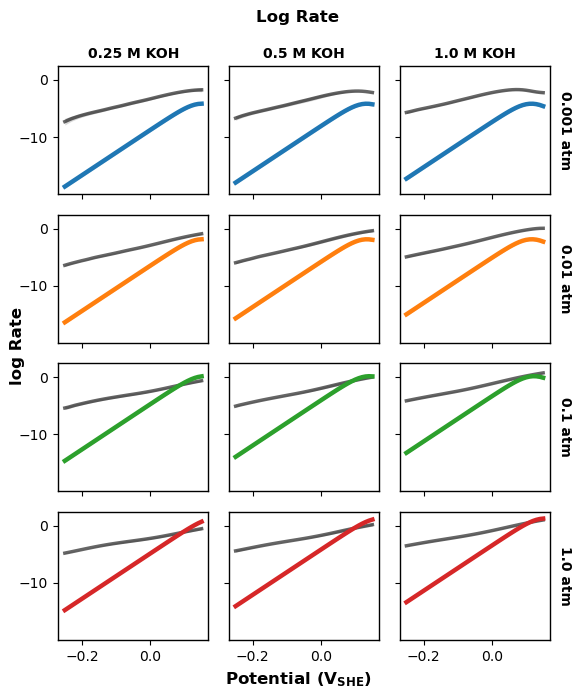

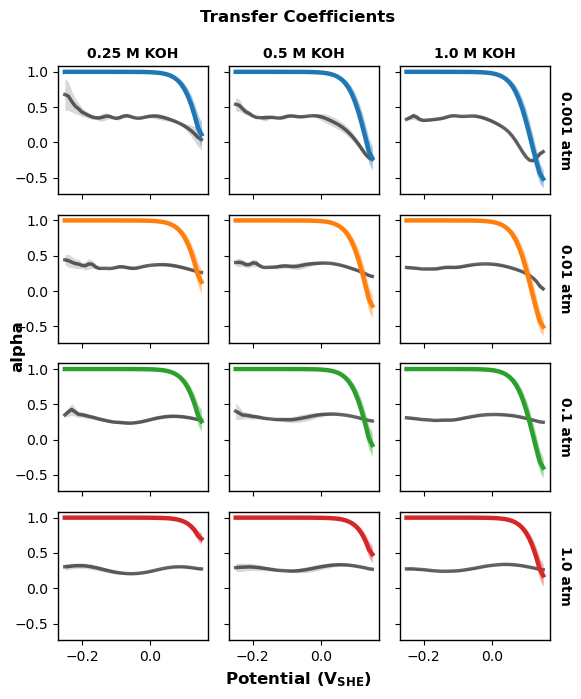

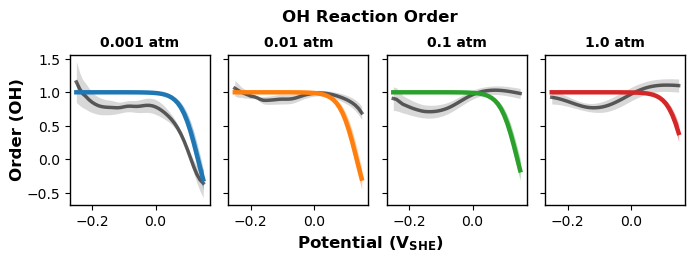

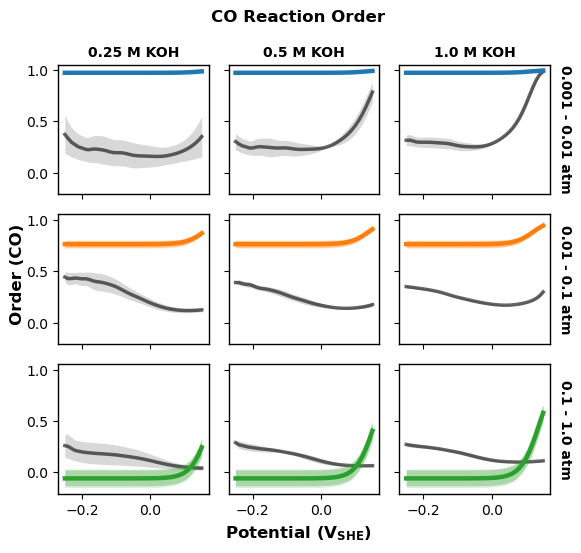

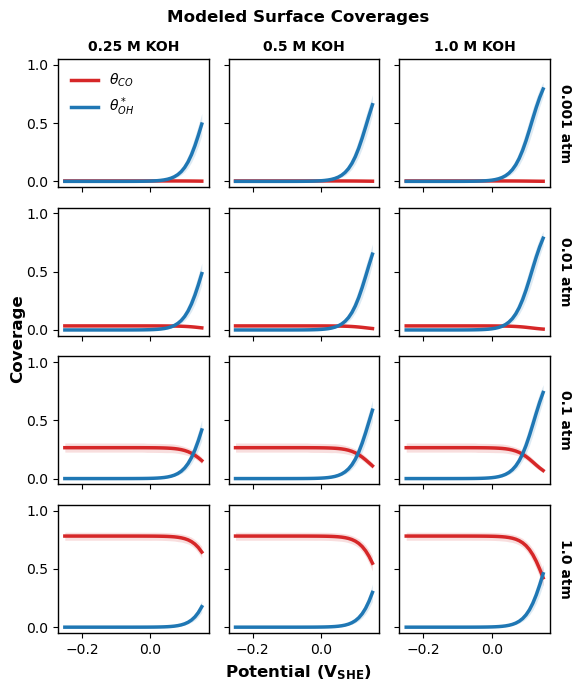

In [6]:
ppc_LH = plot_posteriors(trace_LH, LH)
plot_model_fits(trace_LH, ppc_LH); plot_coverages(trace_LH)

# ER

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.44,15
,3000,0,0.43,7
,3000,0,0.44,15
,3000,0,0.44,15


Computed from 4000 posterior samples and 1476 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  3575.93    56.46
p_loo        6.55        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     1476  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



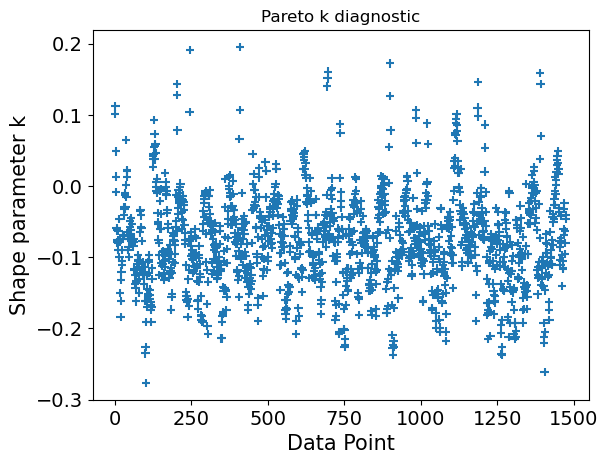

In [7]:
with pm.Model() as ER:
    '''
    1. CO + * <-> CO* (QEA)
    2. CO* + OH- -> COOH* + (e-) (RDS)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2) # at 0V_SHE
    beta_2 = pm.Beta('beta_2', alpha=5, beta=5)   
    Gact2_0 = pm.Normal('Gact2_0', mu=0.7, sigma=0.2) # at 0V_SHE

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    Gact2 = Gact2_0 - beta_2*E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_k2 = np.log(kb_J*T/h) - Gact2/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH_Pd = log_K4 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO)
    log_theta_Pd = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH_Pd]), axis=0)
    log_theta_CO = term_CO + log_theta_Pd
    log_theta_OH_Pd = term_OH_Pd + log_theta_Pd

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH_star = pm.Deterministic('theta_OH_star', pt.exp(log_theta_OH_Pd))
    theta_empty_Pd = pm.Deterministic('theta_empty_Pd', pt.exp(log_theta_Pd))

    # Rate expression
    log_rate = log_k2 + log_theta_CO + np.log(C_KOH_in)
    rate = observables(log_rate) 

trace_ER, loo_ER = fit_and_evaluate(ER)

             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0  -0.147  0.001  -0.149   -0.146      0.000    0.000    2498.0    2737.0    1.0
deltaG4_0   0.108  0.002   0.104    0.113      0.000    0.000    2667.0    2787.0    1.0
Gact2_0     0.769  0.000   0.769    0.770      0.000    0.000    3052.0    3007.0    1.0
beta_2      0.321  0.002   0.317    0.325      0.000    0.000    3229.0    3049.0    1.0
sigma_rel   0.138  0.007   0.125    0.150      0.000    0.000    1893.0    1921.0    1.0
sigma_base  0.000  0.000   0.000    0.000      0.000    0.000    2545.0    1271.0    1.0
exponent    1.493  0.031   1.434    1.552      0.001    0.001    1834.0    1919.0    1.0


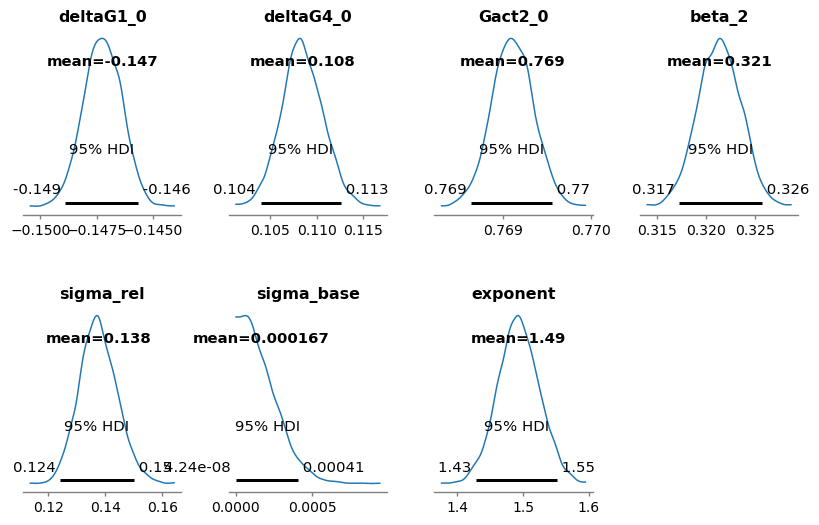

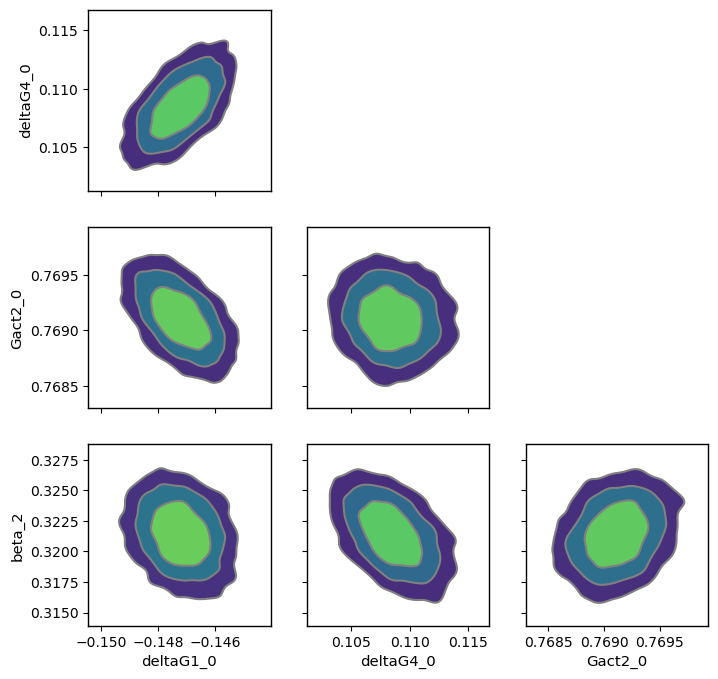

Sampling: [rate]


rate: 0.924


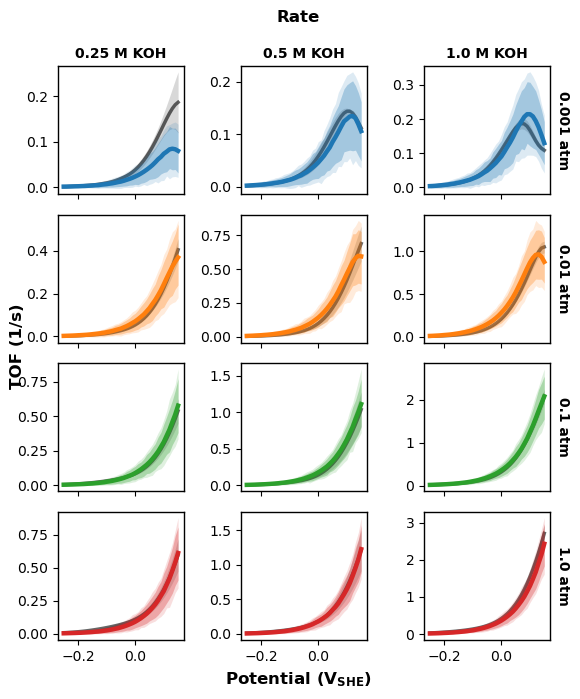

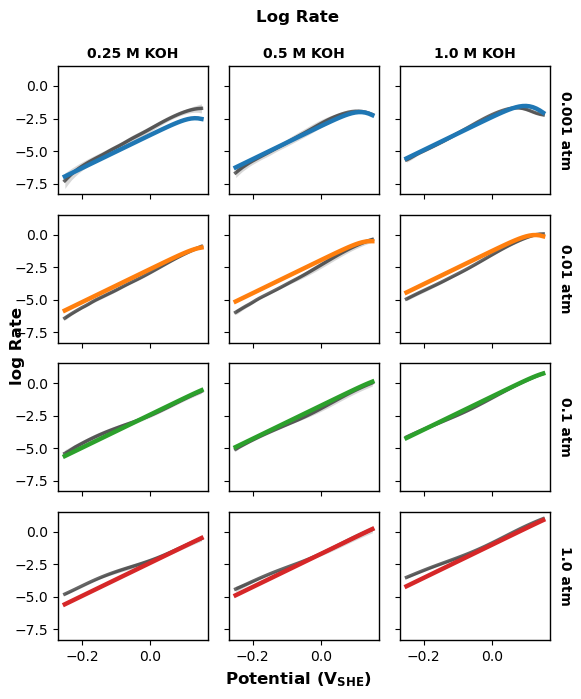

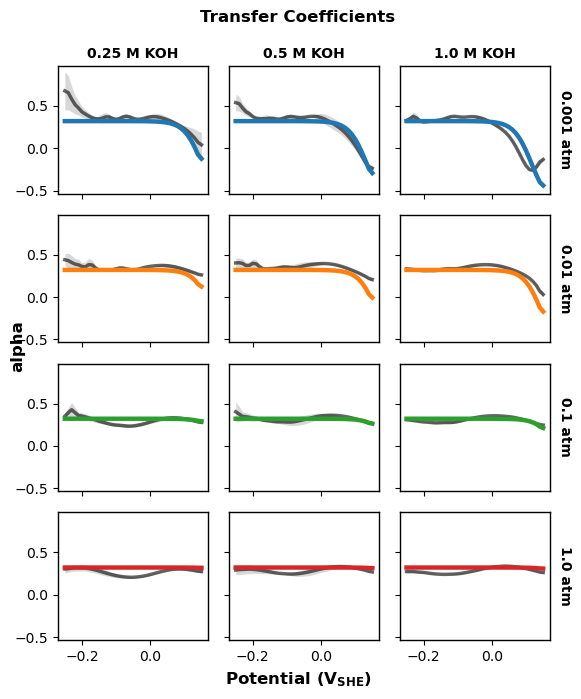

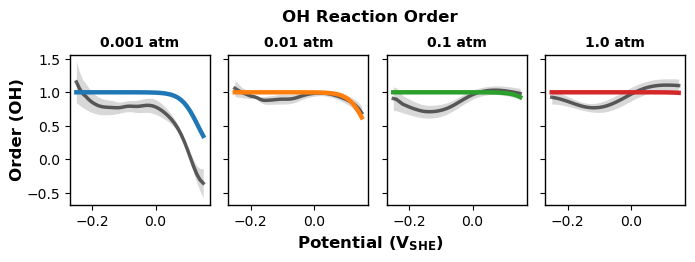

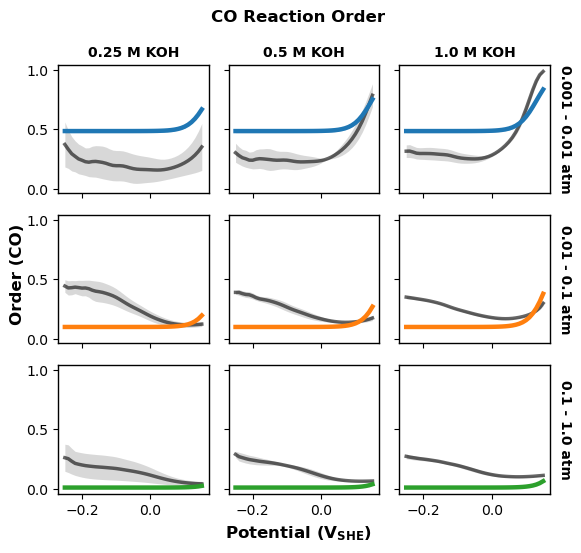

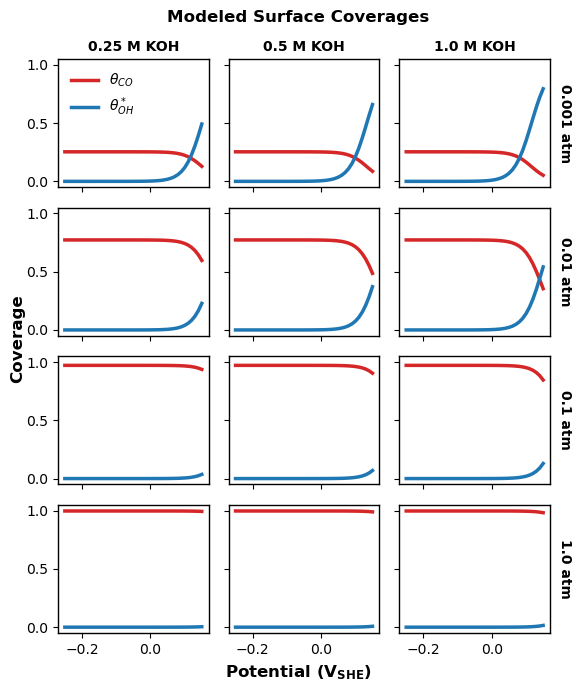

In [8]:
ppc_ER = plot_posteriors(trace_ER, ER)
plot_model_fits(trace_ER, ppc_ER); plot_coverages(trace_ER)

# ER LH

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.47,15
,3000,0,0.41,15
,3000,0,0.48,15
,3000,0,0.47,15


Computed from 4000 posterior samples and 1476 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  3609.87    56.00
p_loo        8.36        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     1476  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



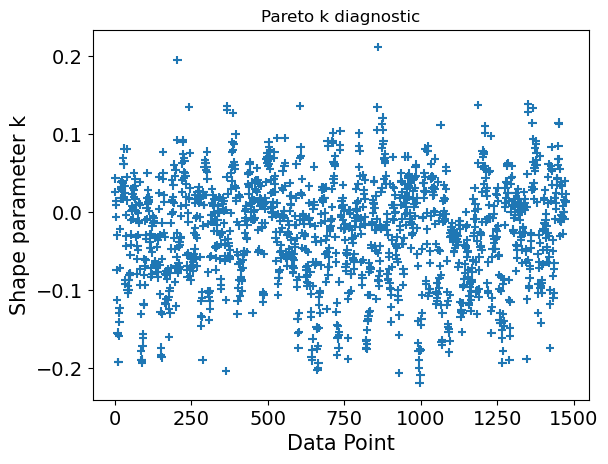

In [11]:
with pm.Model() as ER_LH:
    '''
    1. CO + * <-> CO* (QEA)
    2a. CO* + OH- -> COOH* + (e-) (RDS)
    2b. CO* + OH* -> COOH* + * (RDS)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2) # at 0V_SHE
    beta_2 = pm.Beta('beta_2', alpha=5, beta=5)   
    Gact2_ER_0 = pm.Normal('Gact2_ER_0', mu=0.7, sigma=0.2) # at 0V_SHE
    Gact2_LH_0 = pm.Normal('Gact2_LH_0', mu=0.7, sigma=0.2) # at 0V_SHE

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    Gact2_ER = Gact2_ER_0 - beta_2*E_in
    Gact2_LH = Gact2_LH_0
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_k2_ER = np.log(kb_J*T/h) - Gact2_ER/(kb_eV*T)
    log_k2_LH = np.log(kb_J*T/h) - Gact2_LH/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH_Pd = log_K4 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO)
    log_theta_Pd = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH_Pd]), axis=0)
    log_theta_CO = term_CO + log_theta_Pd
    log_theta_OH_Pd = term_OH_Pd + log_theta_Pd

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH_star = pm.Deterministic('theta_OH_star', pt.exp(log_theta_OH_Pd))
    theta_empty_Pd = pm.Deterministic('theta_empty_Pd', pt.exp(log_theta_Pd))

    # Rate expression
    log_rate_ER = log_k2_ER + log_theta_CO + np.log(C_KOH_in)
    log_rate_LH = log_k2_LH + log_theta_CO + log_theta_OH_Pd
    log_rate = pt.logaddexp(log_rate_ER, log_rate_LH)
    rate = observables(log_rate)

trace_ER_LH, loo_ER_LH = fit_and_evaluate(ER_LH)

             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0  -0.145  0.001  -0.147   -0.143      0.000    0.000    2824.0    2977.0    1.0
deltaG4_0   0.095  0.002   0.091    0.099      0.000    0.000    3353.0    3036.0    1.0
Gact2_ER_0  0.769  0.000   0.769    0.770      0.000    0.000    4180.0    2985.0    1.0
Gact2_LH_0  0.745  0.003   0.739    0.750      0.000    0.000    2585.0    2219.0    1.0
beta_2      0.315  0.002   0.311    0.320      0.000    0.000    3269.0    3035.0    1.0
sigma_rel   0.144  0.007   0.132    0.157      0.000    0.000    2198.0    2148.0    1.0
sigma_base  0.000  0.000   0.000    0.000      0.000    0.000    2184.0    1281.0    1.0
exponent    1.537  0.032   1.478    1.596      0.001    0.001    2119.0    2250.0    1.0


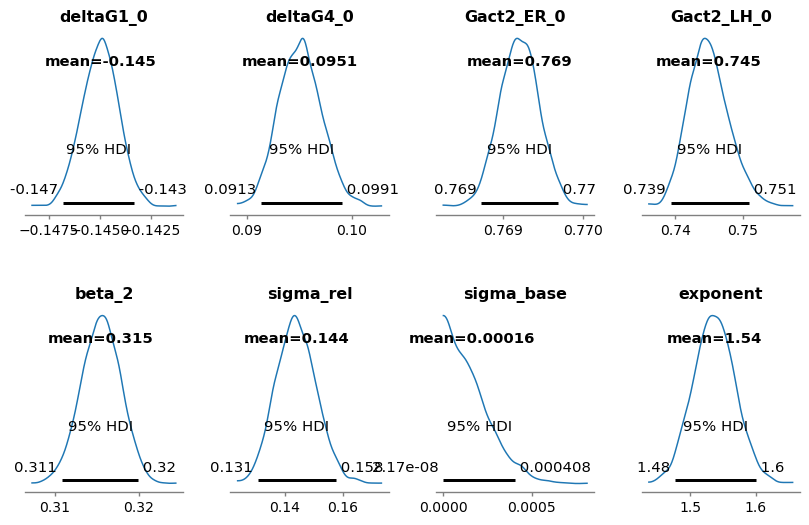

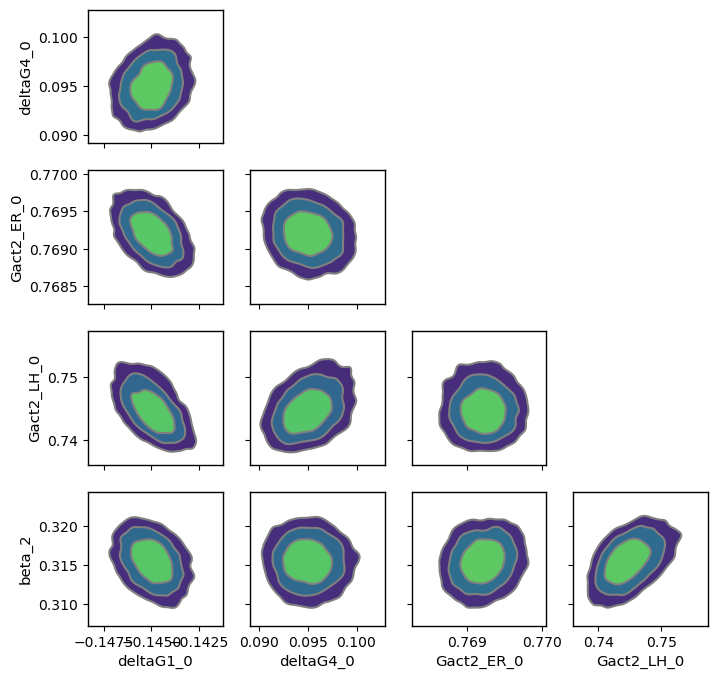

Sampling: [rate]


rate: 0.912


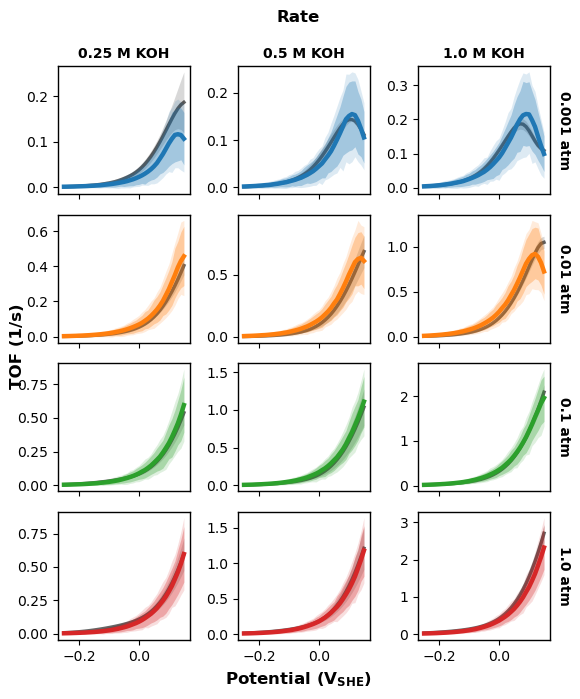

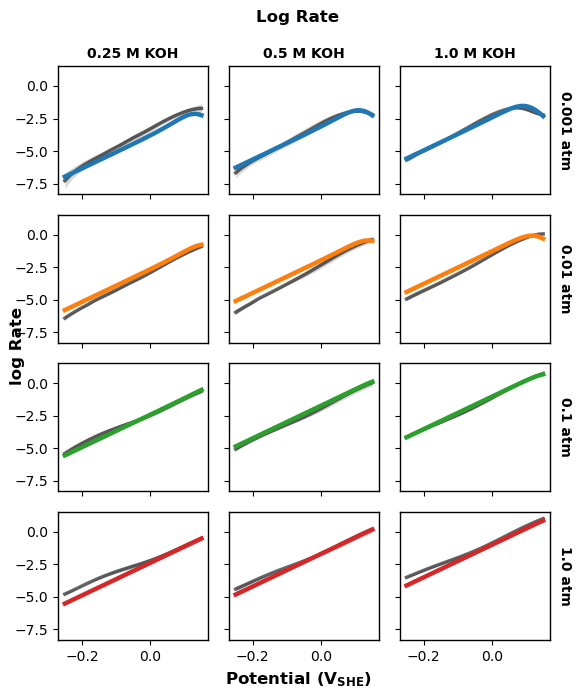

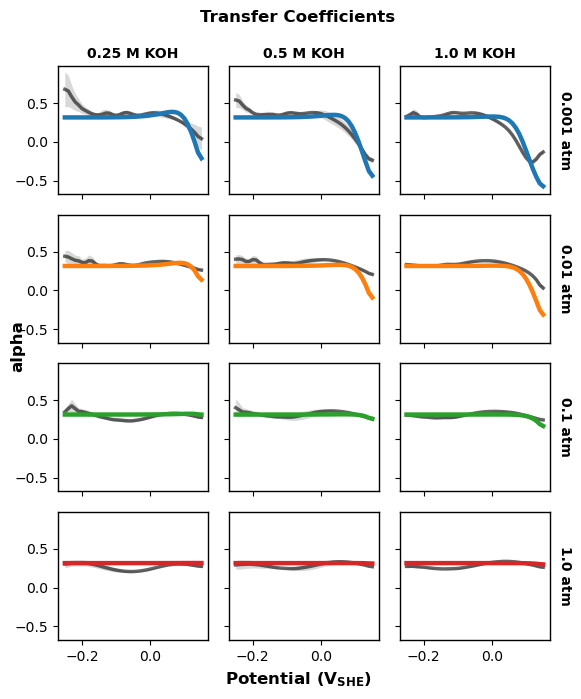

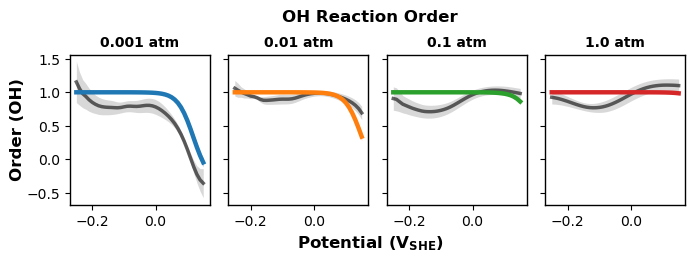

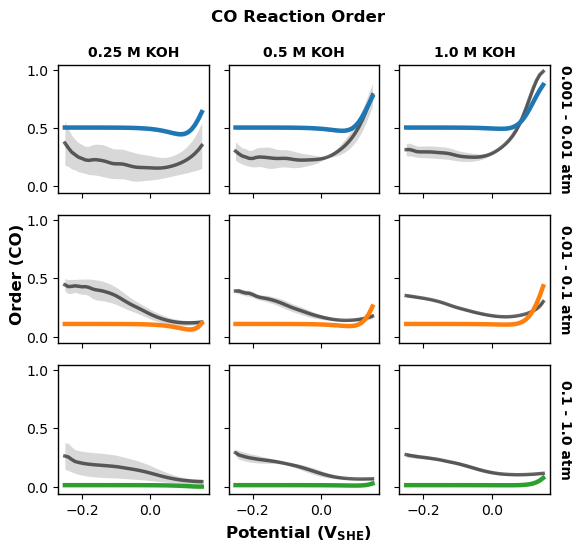

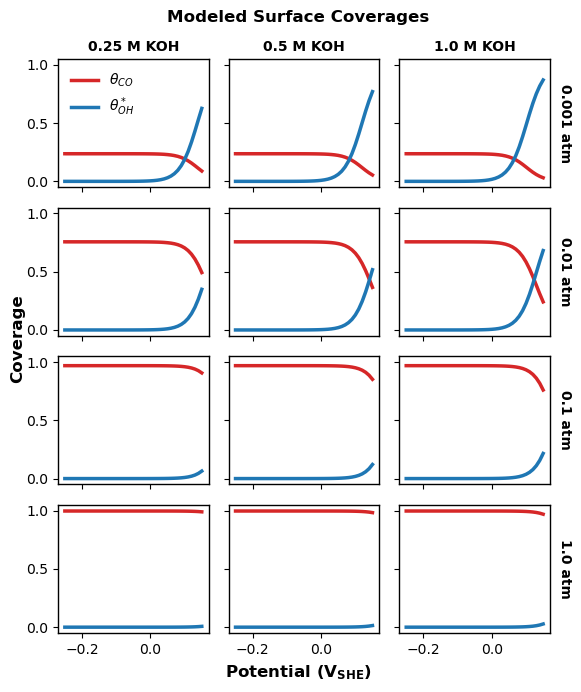

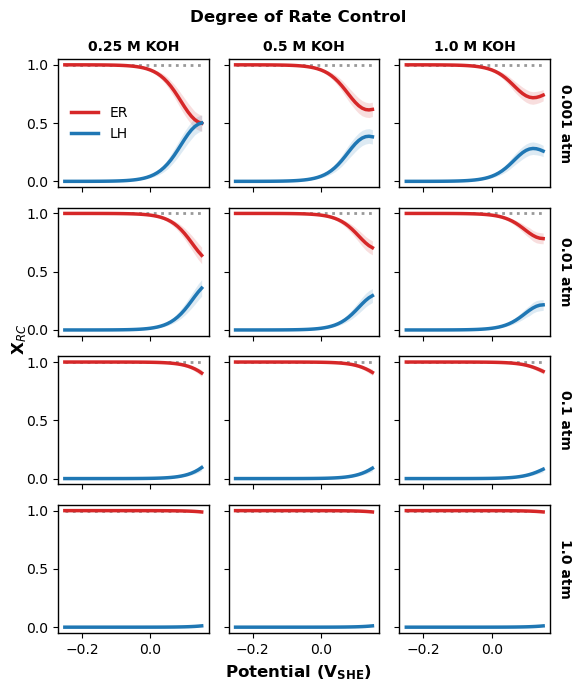

In [12]:
ppc_ER_LH = plot_posteriors(trace_ER_LH, ER_LH)
plot_model_fits(trace_ER_LH, ppc_ER_LH); plot_coverages(trace_ER_LH)
plot_drc(ER_LH, trace_ER_LH, perturb_vars=['Gact2_ER_0', 'Gact2_LH_0'], perturb_labels=['ER', 'LH'])

# Comparison

       rank     elpd_loo     p_loo    elpd_diff        weight         se        dse  warning scale
ER_LH     0  3609.865033  8.362261     0.000000  8.730021e-01  55.996154   0.000000    False   log
ER        1  3575.926006  6.550009    33.939027  1.269979e-01  56.457463  10.347831    False   log
LH        2  1766.902625  5.089666  1842.962409  6.706213e-11  59.734159  27.824158    False   log


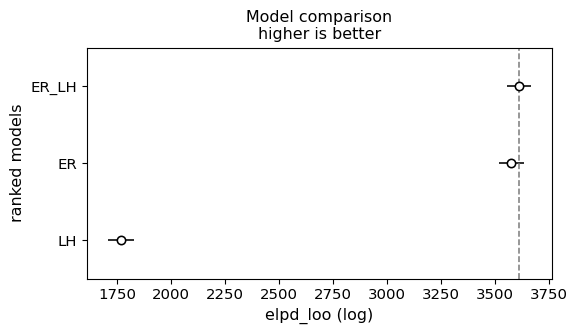

In [13]:
comparison_dict = {
    "LH": loo_LH, # Low ELPD - bad fits
    "ER": loo_ER, 
    "ER_LH": loo_ER_LH,
}

comp_df = az.compare(comparison_dict, ic="loo", method="stacking")
print(comp_df)
az.plot_compare(comp_df, insample_dev=False)
plt.show()